In [21]:
import numpy as np
import random
import matplotlib.pyplot as plt
import copy
from pettingzoo import ParallelEnv

num_agents = 10                   
num_rounds = 200
num_episodes = 100
b = 5           # Benefit
c = 1                    # Cost of cooperation

# Learning parameters        
# chi = 10 / num_episodes    # Reputation assignment error
chi = 0.01

In [22]:
class MatrixGame(ParallelEnv):
    def __init__(self, reward_matrix, agents, alpha=0.0):
        self.agents = agents 
        self.possible_agents = self.agents[:]
        self.reward_matrix = reward_matrix
        self.last_opponent = {}
        self.actions = {}
        self.alpha = alpha

    def reset(self):
        self.agents = self.possible_agents[:]
        self.rewards = {agent: 0.0 for agent in self.agents}
        self.states = {agent: np.random.choice([0,1]) for agent in self.agents}

        return self.states
    
    def get_action_rules(self, action_rule):
        # Convert action_rule_id to 4-bits
        bits = [(action_rule >> i) & 1 for i in range(4)]  # bits[0]=LSB, bits[3]=MSB
        return bits

    def select_new_action(self, action_rule, focal_state, opponent_state):
        if focal_state == 0 and opponent_state == 0:
            return action_rule[3]  # Bit 3
        elif focal_state == 0 and opponent_state == 1:
            return action_rule[2]  # Bit 2
        elif focal_state == 1 and opponent_state == 0:
            return action_rule[1]  # Bit 1
        else:  # (1,1)
            return action_rule[0]  # Bit 0


    def step(self):
        pairings = []
        players = self.agents.copy()
        for _ in range(num_agents//2):
            index = random.randrange(len(players))
            elem1 = players.pop(index)

            index = random.randrange(len(players))
            elem2 = players.pop(index)

            pairings.append((elem1, elem2))




        for pair in pairings:
            action1 = pair[0].select_action(self.states[pair[1]])
            action2 = pair[1].select_action(self.states[pair[0]])

            if action1==5:
                action1 = self.select_new_action(self.get_action_rules(5), self.states[pair[0]], self.states[pair[1]])

            if action2==5:
                action2 = self.select_new_action(self.get_action_rules(5), self.states[pair[1]], self.states[pair[0]])


            self.actions[pair[0]] = action1
            self.actions[pair[1]] = action2

            self.last_opponent[pair[0]] = pair[1]
            self.last_opponent[pair[1]] = pair[0]

            reward1 = self.reward_matrix[action1][action2]
            reward2 = self.reward_matrix[action2][action1]

            # Calculate introspective reward
            intro_action1 = pair[0].select_action(self.states[pair[0]])
            intro_action2 = pair[1].select_action(self.states[pair[1]])

            if intro_action1==5:
                intro_action1 = self.select_new_action(self.get_action_rules(5), self.states[pair[0]], self.states[pair[0]])

            if intro_action2==5:
                intro_action2 = self.select_new_action(self.get_action_rules(5), self.states[pair[1]], self.states[pair[1]])

            intro_reward1 = self.reward_matrix[intro_action1][intro_action1]
            intro_reward2 = self.reward_matrix[intro_action2][intro_action2]


            self.rewards[pair[0]] = (1-self.alpha) * reward1 + self.alpha * intro_reward1 
            self.rewards[pair[1]] = (1-self.alpha) * reward2 + self.alpha * intro_reward2

            judge = random.choice([a for a in self.agents if a not in pair])  # AJOUT

            # AJOUT : état de jugement (action focal, réputation adversaire)
            judge_state_1 = action1 * 2 + self.states[pair[1]] #(Defect,Bad),(Defect,Good), (Coop, Bad), (Defect, Good)
            judge_state_2 = action2 * 2 + self.states[pair[0]]


            state1 = judge.select_judge_action(judge_state_1)  # AJOUT
            state2 = judge.select_judge_action(judge_state_2)  # AJOUT

            judge.store_judgement(judge_state_1, state1)
            judge.store_judgement(judge_state_2, state2)


            if (random.random() < chi):
                state1 = 1-state1
            if (random.random() < chi):
                state2 = 1-state2

            self.states[pair[0]] = state1
            self.states[pair[1]] = state2

        return self.states, self.rewards, self.actions

In [23]:
class Qlearner:
    """A Q-learning agent"""

    def __init__(
        self,
        seeded=False,
        action_size=2,
        state_size=2,
        learning_rate=0.01,
        gamma=0.8,
        epsilon=0.1,
    ):
        self.action_size = action_size
        self.state_size = state_size

        self.seeded = seeded
        # initialize the Q-table: (State x Agent Action)
        self.qtable = np.zeros((self.state_size, self.action_size))

        # --- AJOUT (Section 5) ---
        # Q-table pour juger les autres agents (4 états possibles, 2 actions: rep 0 ou 1)
        self.judge_qtable = np.zeros((4, 2))
        self.judge_memory = []  # stocke les jugements sans reward immédiat
        # ------------------------

        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon

        self.rewards_this_episode = []
        self.episode_total_rewards = []
        self.average_episode_total_rewards = []

        self.state_history = []
        self.action_history = []

    def reset_agent(self):
        self.qtable = np.zeros((self.state_size, self.action_size))
        self.judge_qtable = np.zeros((4, 2))  # --- AJOUT ---
        self.judge_memory = []                # --- AJOUT ---

    def select_greedy(self, state):
        return np.random.choice(
            np.flatnonzero(np.isclose(self.qtable[state], self.qtable[state].max()))
        )

    def select_action(self, state):
        if self.seeded:
            return 5
        if np.random.rand() < self.epsilon:
            action = random.randrange(self.action_size)
        else:
            action = self.select_greedy(state)
        self.state_history.append(state)
        self.action_history.append(action)
        return action

    # --- AJOUT (Section 5) ---
    def select_judge_action(self, judge_state):
        """Choisit la réputation (0 ou 1) à attribuer"""
        if np.random.rand() < self.epsilon:
            return random.randrange(2)
        return np.argmax(self.judge_qtable[judge_state])

    def store_judgement(self, judge_state, judge_action):
        """Stocke le jugement (pas de reward immédiat)"""
        self.judge_memory.append((judge_state, judge_action))
    # ------------------------

    def update(self, state, action, new_state, reward, done):
        lr = self.learning_rate
        self.qtable[state, action] += lr * (
            reward
            + (not done) * self.gamma * np.max(self.qtable[new_state])
            - self.qtable[state, action]
        )

        self.rewards_this_episode.append(reward)

        if done:
            episode_reward = self._calculate_episode_reward(
                self.rewards_this_episode, discount=False
            )
            self.episode_total_rewards.append(episode_reward)

            k = len(self.average_episode_total_rewards) + 1
            self._calculate_average_episode_reward(k, episode_reward)

            # --- AJOUT (Section 5) ---
            # Le reward final rétro-propage sur les jugements passés
            for s_j, a_j in self.judge_memory:
                self.judge_qtable[s_j, a_j] += lr * (
                    episode_reward - self.judge_qtable[s_j, a_j]
                )
            self.judge_memory = []
            # ------------------------

            self.rewards_this_episode = []

    def _calculate_episode_reward(self, rewards_this_episode, discount=False):
        if discount:
            return sum(
                [self.gamma ** i * reward for i, reward in enumerate(rewards_this_episode)]
            )
        return sum(rewards_this_episode)

    def _calculate_average_episode_reward(self, k, episode_reward):
        if k > 1:
            average_episode_reward = (
                (1 - 1 / k) * self.average_episode_total_rewards[-1]
                + episode_reward / k
            )
        else:
            average_episode_reward = episode_reward
        self.average_episode_total_rewards.append(average_episode_reward)

    def print_rewards(self, episode, print_epsilon=True, print_q_table=True):
        print("Total reward:", self.episode_total_rewards[episode])
        print("Average reward:", self.average_episode_total_rewards[-1])
        if print_epsilon:
            print("Epsilon:", self.epsilon)
        if print_q_table:
            print("Q-table:", self.qtable)


In [24]:
def run(payoffs,  alpha, seed_number):
    run = 46
    np.random.seed(run)
    random.seed(run)

    agents = [Qlearner(seeded=True) for _ in range(seed_number)] + [Qlearner(seeded=False) for _ in range(10-seed_number)]
    env = MatrixGame(payoffs, agents, alpha)


    for episode in range(num_episodes):
        if episode%100==0:
            print(f"Number of episodes: {episode}")
        obs = env.reset()
        prev_obs = None
        prev_actions = {}
        prev_rewards = {}
        prev_opponents = {}
        for round in range(num_rounds):
            
            next_obs, rewards, actions = env.step()
            last_opponent = env.last_opponent
            if prev_obs is not None:
                for agent in agents:
                    s = prev_obs[prev_opponents[agent]]
                    a = prev_actions[agent]
                    r = prev_rewards[agent]
                    s_next = obs[last_opponent[agent]]
                    agent.update(s, a, s_next, r, done=False)
            prev_obs = obs
            prev_actions = actions
            prev_rewards = rewards
            prev_opponents = last_opponent
            obs = next_obs

        for agent in agents:
            s = prev_obs[prev_opponents[agent]]
            a = prev_actions[agent]
            r = prev_rewards[agent]
            s_next = obs[last_opponent[agent]]

            agent.update(s, a, s_next, r, done=True)

    average_agent_round_payoff = np.zeros(num_episodes//2)
    for agent in agents:
        average_round_payoff = np.array(agent.episode_total_rewards[num_episodes//2:])/num_rounds
        average_agent_round_payoff += average_round_payoff

    b = payoffs[0,1]
    average_agent_round_payoff = (average_agent_round_payoff.sum()/(10*(num_episodes//2)))/(b-c)

    return average_agent_round_payoff

Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of episodes: 0
Number of 

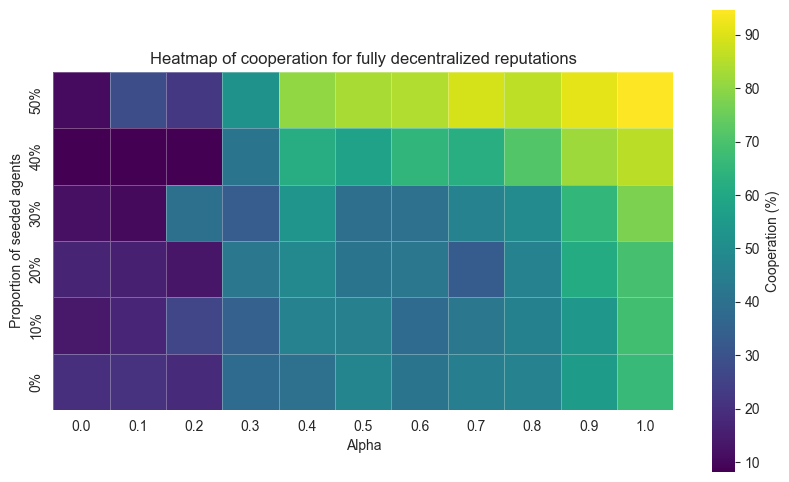

In [25]:

import seaborn as sns
payoffs = np.array([[0, b],[-c, b-c]])


seeded_list = [0, 1, 2, 3, 4, 5]  # nombre de seeded agents
alpha_list = np.linspace(0, 1, 11)


seeded_prop = np.array(seeded_list)


coop_matrix = np.zeros((len(seeded_list), len(alpha_list)))

for i, seed in enumerate(seeded_list):
    for j, alpha in enumerate(alpha_list):
        coop_matrix[i, j] = run(payoffs, alpha, seed) * 100


plt.figure(figsize=(10, 6))
sns.heatmap(
    coop_matrix,
    xticklabels=np.round(alpha_list, 2),
    yticklabels=[f"{int(p*10)}%" for p in seeded_prop[::-1]],
    cmap="viridis",
    cbar_kws={'label': 'Cooperation (%)'},
    linewidths=0.5,
    linecolor=(1,1,1,0.3),
    square=True
)
plt.xlabel("Alpha")
plt.ylabel("Proportion of seeded agents")
plt.title("Heatmap of cooperation for fully decentralized reputations")
plt.show()